In [41]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [43]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

In [44]:
sample_data = [
    ("Pen", 10, 5.0),
    ("Notebook", 5, 20.0),
    ("Pen", 7, 5.0),
    ("Eraser", 15, 2.0),
    ("Notebook", 3, 20.0),
    ("Marker", 6, 10.0)
]

In [45]:
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [46]:
query = '''
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''

In [47]:
df = pd.read_sql_query(query, conn)

In [48]:
print("Sales Summary:")
print(df)

Sales Summary:
    product  total_qty  revenue
0    Eraser         75    150.0
1    Marker         30    300.0
2  Notebook         40    800.0
3       Pen         85    425.0


In [50]:
query2 = '''
SELECT product,
       SUM(quantity) AS total_quantity
FROM sales
GROUP BY product
ORDER BY total_quantity DESC
LIMIT 1
'''

In [51]:
df_top_qty = pd.read_sql_query(query2, conn)
print("Best-Selling Product by Quantity:")
print(df_top_qty)

Best-Selling Product by Quantity:
  product  total_quantity
0     Pen              85


In [52]:
query3 = '''
SELECT product,
       SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC
LIMIT 1
'''

In [54]:
df_top_revenue = pd.read_sql_query(query3, conn)
print("Top Revenue Product:")
print(df_top_revenue)


Top Revenue Product:
    product  total_revenue
0  Notebook          800.0


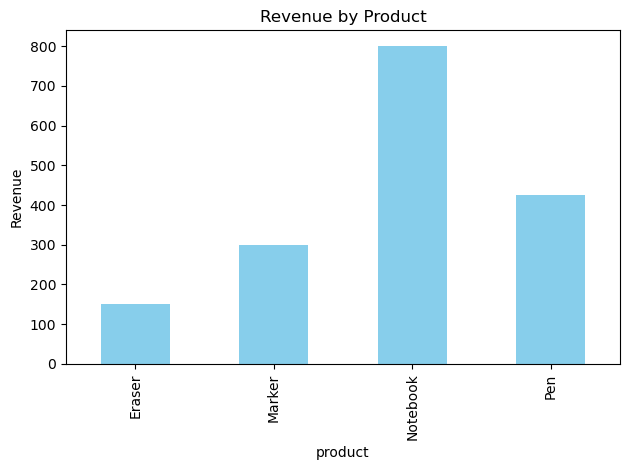

In [49]:
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [ ]:
conn.close()
